# Attack Label Analysis

This notebook analyses the enriched labeled files across all four test datasets:
- `hai-test1-labeled.csv` — HAI physical layer, test split 1
- `hai-test2-labeled.csv` — HAI physical layer, test split 2
- `end-test1-labeled.csv` — HAIEnd DCS layer, test split 1
- `end-test2-labeled.csv` — HAIEnd DCS layer, test split 2

**Questions answered:**
1. What fraction of each file is under attack vs normal?
2. How do attacks distribute over time in each file?
3. What is the breakdown of AP vs AE attacks in test1 vs test2?
4. Which attacks appear in HAI only vs both HAI and HAIEnd, and why?

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.1)

LABELED_DIR = os.environ.get('OUT_DIR', 'C:/Users/ahmma/Desktop/farah/labeled')

files = {
    'hai-test1': (os.path.join(LABELED_DIR, 'hai-test1-labeled.csv'), 'timestamp'),
    'hai-test2': (os.path.join(LABELED_DIR, 'hai-test2-labeled.csv'), 'timestamp'),
    'end-test1': (os.path.join(LABELED_DIR, 'end-test1-labeled.csv'), 'Timestamp'),
    'end-test2': (os.path.join(LABELED_DIR, 'end-test2-labeled.csv'), 'Timestamp'),
}

dfs = {}
for name, (path, ts_col) in files.items():
    df = pd.read_csv(path, low_memory=False, parse_dates=[ts_col])
    df = df.rename(columns={ts_col: 'timestamp'})
    dfs[name] = df
    print(f'{name}: {len(df):,} rows, columns={df.shape[1]}')

hai-test1: 54,000 rows, columns=93
hai-test2: 230,400 rows, columns=93
end-test1: 54,000 rows, columns=232
end-test2: 230,400 rows, columns=232


## 1. Overview — Attack vs Normal row counts

In [2]:
rows = []
for name, df in dfs.items():
    total = len(df)
    attack = (df['attack_type'] != 'normal').sum()
    normal = total - attack
    rows.append({
        'file': name,
        'total': total,
        'normal': normal,
        'attack': attack,
        'attack_%': round(100 * attack / total, 2)
    })

overview = pd.DataFrame(rows)
print(overview.to_string(index=False))

     file  total  normal  attack  attack_%
hai-test1  54000   51019    2981      5.52
hai-test2 230400  221997    8403      3.65
end-test1  54000   51019    2981      5.52
end-test2 230400  221997    8403      3.65


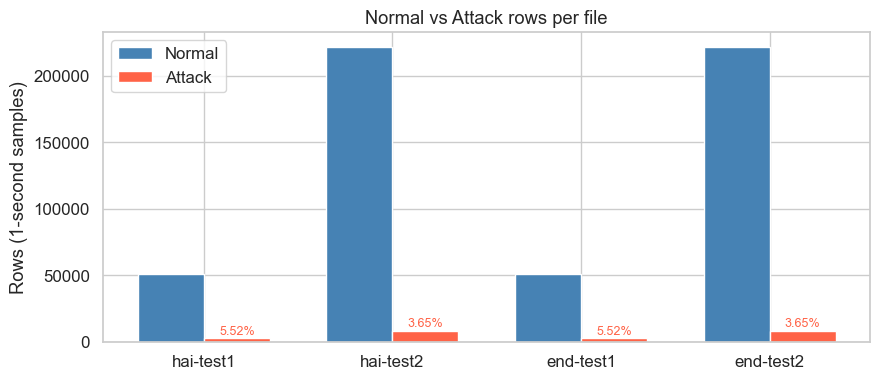

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))

x = np.arange(4)
w = 0.35
ax.bar(x - w/2, overview['normal'],  w, label='Normal', color='steelblue')
ax.bar(x + w/2, overview['attack'],  w, label='Attack',  color='tomato')

for i, row in overview.iterrows():
    ax.text(i + w/2, row['attack'] + 500, f"{row['attack_%']}%",
            ha='center', va='bottom', fontsize=9, color='tomato')

ax.set_xticks(x)
ax.set_xticklabels(overview['file'])
ax.set_ylabel('Rows (1-second samples)')
ax.set_title('Normal vs Attack rows per file')
ax.legend()
plt.tight_layout()
plt.show()

**Observation:** Attacks make up only a small fraction of each file (~2-4%). 
Test2 has far more rows (230,400 vs 54,000) because more attack scenarios were included and more normal operation time was recorded.

## 2. Attack Timeline — When do attacks occur in each file?

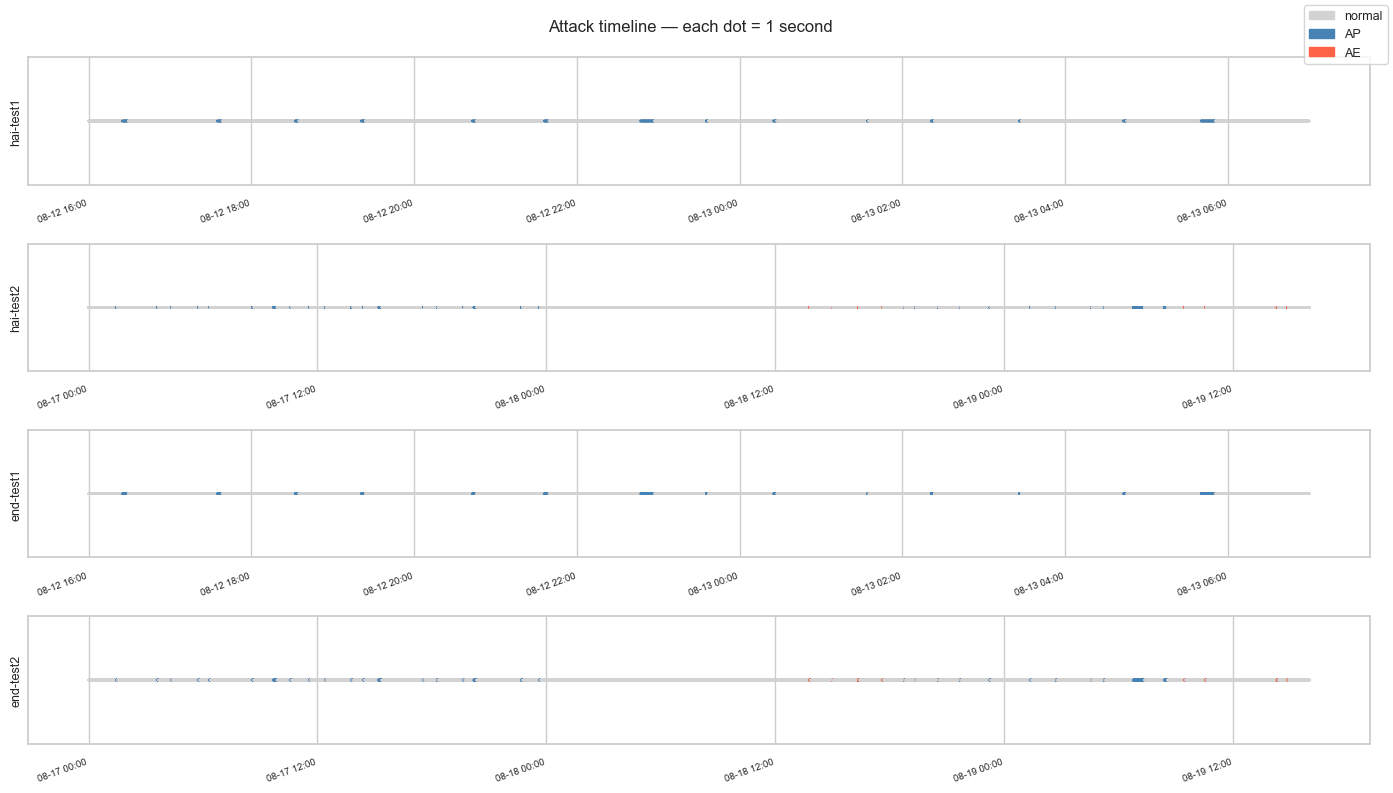

In [4]:
TYPE_COLOR = {'normal': 'lightgrey', 'AP': 'steelblue', 'AE': 'tomato'}

fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=False)

for ax, (name, df) in zip(axes, dfs.items()):
    colors = df['attack_type'].map(TYPE_COLOR)
    ax.scatter(df['timestamp'], np.zeros(len(df)),
               c=colors, s=0.3, alpha=0.6)
    ax.set_ylabel(name, fontsize=9)
    ax.set_yticks([])
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=20, ha='right', fontsize=7)

patches = [mpatches.Patch(color=c, label=l) for l, c in TYPE_COLOR.items()]
fig.legend(handles=patches, loc='upper right', fontsize=9)
fig.suptitle('Attack timeline — each dot = 1 second', fontsize=12)
plt.tight_layout()
plt.show()

**Observation:** 
- **test1** is a single overnight session (Aug 12–13): all attacks are AP (blue), evenly spaced.
- **test2** spans several days (Aug 17–19): AP attacks dominate, with 8 AE attacks (red) clustered on Aug 18–19.
- **HAI and HAIEnd timelines are identical** for the same split — every attack window appears in both files.

## 3. Test1 vs Test2 — Attack type breakdown

In [5]:
# Count unique attack instances (not rows) per split
for split_name, name in [('Test 1', 'hai-test1'), ('Test 2', 'hai-test2')]:
    df = dfs[name]
    attacks = df[df['attack_type'] != 'normal'].drop_duplicates('attack_id')
    print(f"\n=== {split_name} ({name}) ===")
    summary = attacks.groupby(['attack_type', 'combination']).size().reset_index(name='count')
    summary['label'] = summary['attack_type'] + ' / combination=' + summary['combination']
    print(summary[['label', 'count']].to_string(index=False))
    print(f"Total unique attacks: {len(attacks)}")


=== Test 1 (hai-test1) ===
              label  count
AP / combination=no     14
Total unique attacks: 14

=== Test 2 (hai-test2) ===
               label  count
 AE / combination=no      8
 AP / combination=no     20
AP / combination=yes     10
Total unique attacks: 38


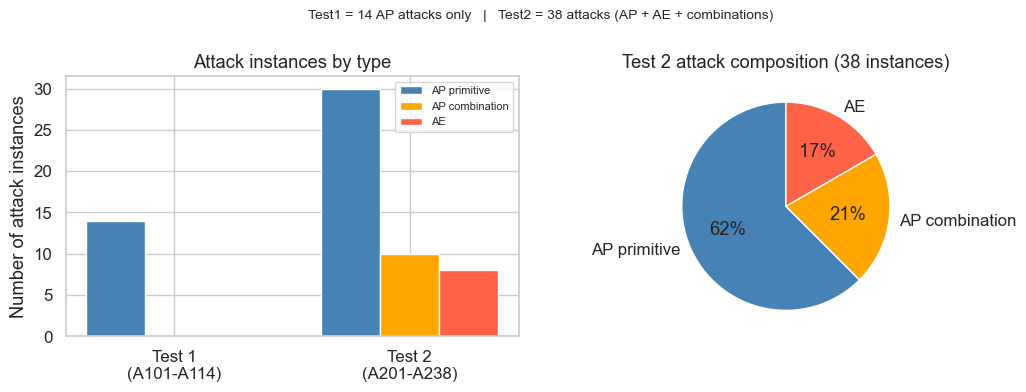

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

split_labels  = ['Test 1\n(A101-A114)', 'Test 2\n(A201-A238)']
ap_primitive  = [14, 30]   # AP, combination=no
ap_combo      = [0,  10]   # AP, combination=yes
ae_attacks    = [0,  8]    # AE

x = np.arange(2)
w = 0.25

axes[0].bar(x - w, ap_primitive, w, label='AP primitive', color='steelblue')
axes[0].bar(x,     ap_combo,     w, label='AP combination', color='orange')
axes[0].bar(x + w, ae_attacks,   w, label='AE',            color='tomato')
axes[0].set_xticks(x)
axes[0].set_xticklabels(split_labels)
axes[0].set_ylabel('Number of attack instances')
axes[0].set_title('Attack instances by type')
axes[0].legend(fontsize=8)

# Pie chart for test2 composition
axes[1].pie([30, 10, 8],
            labels=['AP primitive', 'AP combination', 'AE'],
            colors=['steelblue', 'orange', 'tomato'],
            autopct='%1.0f%%', startangle=90)
axes[1].set_title('Test 2 attack composition (38 instances)')

plt.suptitle('Test1 = 14 AP attacks only   |   Test2 = 38 attacks (AP + AE + combinations)', fontsize=10)
plt.tight_layout()
plt.show()

**Key difference between Test1 and Test2:**

| | Test 1 | Test 2 |
|---|---|---|
| AP primitive | 14 | 30 |
| AP combination | 0 | 10 |
| AE | 0 | 8 |
| **Total** | **14** | **48** |

Test 1 is a warm-up: only simple AP attacks, one controller at a time.  
Test 2 is the full challenge: adds AE attacks (internal DCS) and combination attacks (two controllers hit simultaneously).

## 4. HAI vs HAIEnd — Which attacks appear where and why?

In [7]:
# For test2: compare attack_id presence in hai vs end
hai2 = dfs['hai-test2']
end2 = dfs['end-test2']

hai_attacks = set(hai2[hai2['attack_type'] != 'normal']['attack_id'].unique())
end_attacks = set(end2[end2['attack_type'] != 'normal']['attack_id'].unique())

print(f"Attacks in hai-test2:  {sorted(hai_attacks)}")
print(f"Attacks in end-test2:  {sorted(end_attacks)}")
print(f"\nIn HAI but not HAIEnd: {sorted(hai_attacks - end_attacks)}")
print(f"In both:               {sorted(hai_attacks & end_attacks)}")

Attacks in hai-test2:  ['A201', 'A202', 'A203', 'A204', 'A205', 'A206', 'A207', 'A208', 'A209', 'A210', 'A211', 'A212', 'A213', 'A214', 'A215', 'A216', 'A217', 'A218', 'A219', 'A220', 'A221', 'A222', 'A223', 'A224', 'A225', 'A226', 'A227', 'A228', 'A229', 'A230', 'A231', 'A232', 'A233', 'A234', 'A235', 'A236', 'A237', 'A238']
Attacks in end-test2:  ['A201', 'A202', 'A203', 'A204', 'A205', 'A206', 'A207', 'A208', 'A209', 'A210', 'A211', 'A212', 'A213', 'A214', 'A215', 'A216', 'A217', 'A218', 'A219', 'A220', 'A221', 'A222', 'A223', 'A224', 'A225', 'A226', 'A227', 'A228', 'A229', 'A230', 'A231', 'A232', 'A233', 'A234', 'A235', 'A236', 'A237', 'A238']

In HAI but not HAIEnd: []
In both:               ['A201', 'A202', 'A203', 'A204', 'A205', 'A206', 'A207', 'A208', 'A209', 'A210', 'A211', 'A212', 'A213', 'A214', 'A215', 'A216', 'A217', 'A218', 'A219', 'A220', 'A221', 'A222', 'A223', 'A224', 'A225', 'A226', 'A227', 'A228', 'A229', 'A230', 'A231', 'A232', 'A233', 'A234', 'A235', 'A236', 'A237

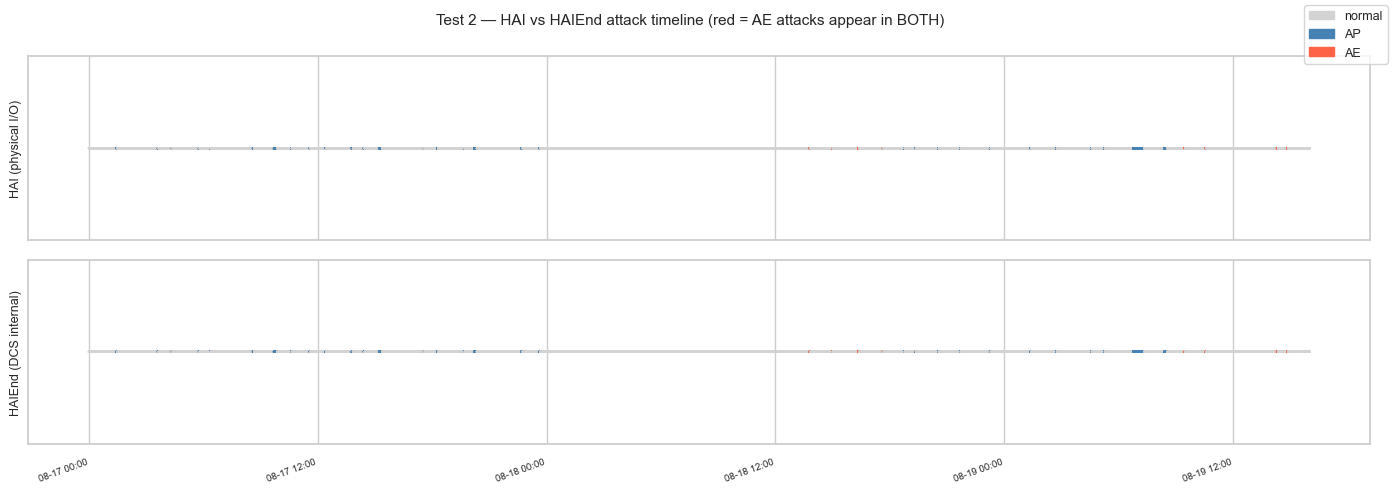

In [8]:
# Side-by-side timeline: HAI vs HAIEnd test2, coloured by attack_type
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

for ax, name, label in [(ax1, 'hai-test2', 'HAI (physical I/O)'),
                         (ax2, 'end-test2', 'HAIEnd (DCS internal)')]:
    df = dfs[name]
    colors = df['attack_type'].map(TYPE_COLOR)
    ax.scatter(df['timestamp'], np.zeros(len(df)), c=colors, s=0.3, alpha=0.7)
    ax.set_ylabel(label, fontsize=9)
    ax.set_yticks([])

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=20, ha='right', fontsize=7)

patches = [mpatches.Patch(color=c, label=l) for l, c in TYPE_COLOR.items()]
fig.legend(handles=patches, loc='upper right', fontsize=9)
fig.suptitle('Test 2 — HAI vs HAIEnd attack timeline (red = AE attacks appear in BOTH)', fontsize=11)
plt.tight_layout()
plt.show()

**Why do AE attacks appear in both HAI and HAIEnd?**

```
AP attacks  →  target HAI I/O points directly
               HAI sees it.  HAIEnd does NOT (DCS not involved)

AE attacks  →  target HAIEnd internal DCS parameters
               HAIEnd sees it immediately.
               Effect propagates to physical sensors → HAI sees it too.
               dataset = 'both'
```

This is why `dataset` column is `hai` for AP and `both` for AE.

In [9]:
# Show the 8 AE attacks side by side: row count in HAI vs HAIEnd
ae_ids = ['A220', 'A221', 'A222', 'A223', 'A235', 'A236', 'A237', 'A238']

rows = []
for aid in ae_ids:
    hai_rows = (dfs['hai-test2']['attack_id'] == aid).sum()
    end_rows = (dfs['end-test2']['attack_id'] == aid).sum()
    scenario = dfs['hai-test2'][dfs['hai-test2']['attack_id'] == aid]['scenario'].iloc[0]
    rows.append({'attack_id': aid, 'scenario': scenario,
                 'rows_in_HAI': hai_rows, 'rows_in_HAIEnd': end_rows})

ae_df = pd.DataFrame(rows)
print(ae_df.to_string(index=False))

attack_id scenario  rows_in_HAI  rows_in_HAIEnd
     A220     AE03          132             132
     A221     AE08           83              83
     A222     AE01          212             212
     A223     AE07           80              80
     A235     AE05           87              87
     A236     AE06          120             120
     A237     AE05          190             190
     A238     AE06          123             123


## 5. Attack Duration Distribution

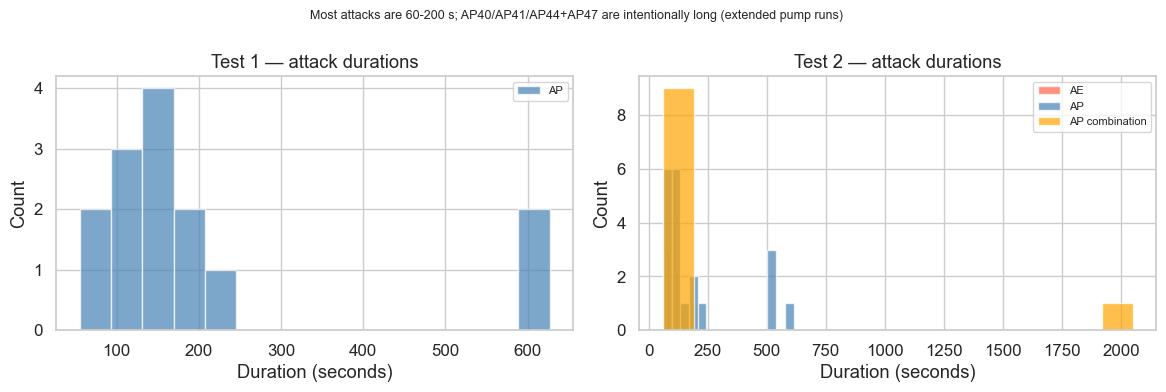

                count   mean    std   min    25%    50%    75%     max
type_label                                                            
AE                8.0  127.4   49.3  79.0   85.0  120.5  145.5   211.0
AP               34.0  211.0  175.5  55.0  102.5  133.0  202.5   627.0
AP combination   10.0  314.0  611.0  60.0  109.0  125.0  153.8  2051.0


In [ ]:
import sys
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), 'hai-digital-twin'))
sys.path.insert(0, '..')

timetable = pd.read_csv('../data/test_data.csv', parse_dates=['start', 'end'])
timetable['split_label'] = timetable['split'].map({int(k): v for k, v in {1: 'Test 1', 2: 'Test 2'}.items()})
timetable['type_label'] = timetable.apply(
    lambda r: 'AP combination' if r['combination'] == 'yes' else r['attack_type'], axis=1
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pal = {'AP': 'steelblue', 'AE': 'tomato', 'AP combination': 'orange'}

for ax, (split, grp) in zip(axes, timetable.groupby('split_label')):
    for ttype, sub in grp.groupby('type_label'):
        ax.hist(sub['duration_sec'], bins=15, alpha=0.7,
                color=pal.get(ttype, 'grey'), label=ttype)
    ax.set_xlabel('Duration (seconds)')
    ax.set_ylabel('Count')
    ax.set_title(f'{split} — attack durations')
    ax.legend(fontsize=8)

plt.suptitle('Most attacks are 60-200 s; AP40/AP41/AP44+AP47 are intentionally long (extended pump runs)', fontsize=9)
plt.tight_layout()
plt.show()

print(timetable.groupby('type_label')['duration_sec'].describe().round(1))

## 6. Attack density per controller

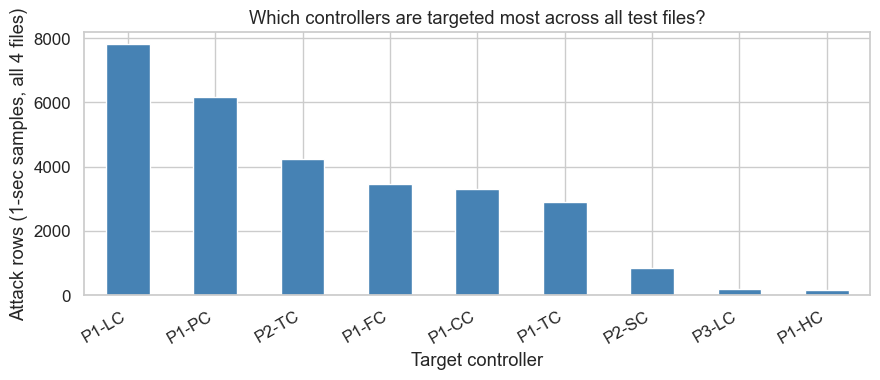

In [ ]:
# Count attack-rows per target_controller across all 4 files combined
combined = pd.concat(
    [df[['timestamp', 'attack_type', 'target_controller', 'combination']]
     for df in dfs.values()],
    ignore_index=True
)

attack_rows = combined[combined['attack_type'] != 'normal']

# For combination attacks the controller field has both ("P1-LC / P2-SC") — split and count separately
ctrl_counts = (
    attack_rows['target_controller']
    .str.split(' / ')
    .explode()
    .str.strip()
    .value_counts()
)

fig, ax = plt.subplots(figsize=(9, 4))
ctrl_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Target controller')
ax.set_ylabel('Attack rows (1-sec samples, all 4 files)')
ax.set_title('Which controllers are targeted most across all test files?')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 7. Summary

| Question | Answer |
|----------|--------|
| How many rows are under attack? | ~2-4% per file — heavily imbalanced |
| Test1 vs Test2 | Test1 = 14 simple AP; Test2 = 38 attacks (AP + AE + combinations) |
| HAI vs HAIEnd | AP attacks in HAI only; AE attacks in **both** (DCS → physical propagation) |
| Attack durations | Most are 60–200 s; a few long ones (AP40/AP41/AP44+AP47) exceed 600 s |
| Most targeted controller | P1-LC and P1-PC appear most across all test files |

**For modelling:**
- Use `attack_type` as your label (`normal` / `AP` / `AE`).
- Handle class imbalance (SMOTE, class weights, or focal loss).
- AE detection requires HAIEnd features; AP detection can use HAI alone.
- Combination attacks (A224-A233) are harder — two controllers diverge simultaneously.

## 8. Most Affected Sensors
Sensors with the largest normalised mean shift between normal and attack rows (hai-test2).

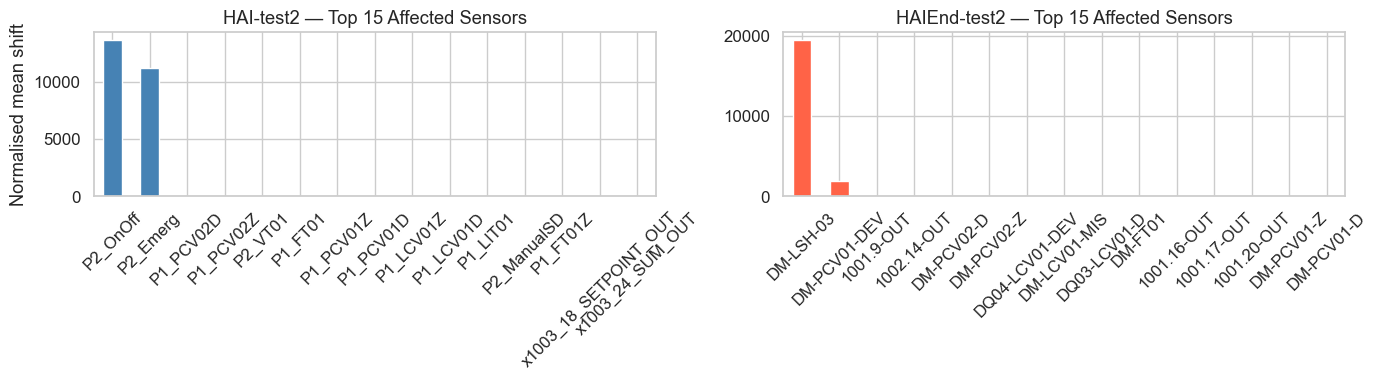

HAI top sensors: ['P2_OnOff', 'P2_Emerg', 'P1_PCV02D', 'P1_PCV02Z', 'P2_VT01', 'P1_FT01', 'P1_PCV01Z', 'P1_PCV01D', 'P1_LCV01Z', 'P1_LCV01D', 'P1_LIT01', 'P2_ManualSD', 'P1_FT01Z', 'x1003_18_SETPOINT_OUT', 'x1003_24_SUM_OUT']
HAIEnd top sensors: ['DM-LSH-03', 'DM-PCV01-DEV', '1001.9-OUT', '1002.14-OUT', 'DM-PCV02-D', 'DM-PCV02-Z', 'DQ04-LCV01-DEV', 'DM-LCV01-MIS', 'DQ03-LCV01-D', 'DM-FT01', '1001.16-OUT', '1001.17-OUT', '1001.20-OUT', 'DM-PCV01-Z', 'DM-PCV01-D']


In [13]:
hai2 = dfs["hai-test2"].copy()
end2 = dfs["end-test2"].copy()

META = {"timestamp", "attack", "attack_id", "scenario", "attack_type",
        "combination", "target_controller", "target_points"}

def top_affected(df, n=15):
    sensor_cols = [c for c in df.select_dtypes(include=["number"]).columns
                   if c.lower() not in {m.lower() for m in META}]
    normal = df[df["attack_type"] == "normal"][sensor_cols]
    attack = df[df["attack_type"] != "normal"][sensor_cols]
    shift = ((attack.mean() - normal.mean()).abs() /
             (normal.std() + 1e-6)).sort_values(ascending=False)
    return shift.head(n)

top_hai = top_affected(hai2)
top_end = top_affected(end2)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
top_hai.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("HAI-test2 — Top 15 Affected Sensors")
axes[0].set_ylabel("Normalised mean shift")
axes[0].tick_params(axis="x", rotation=45)
top_end.plot(kind="bar", ax=axes[1], color="tomato", edgecolor="white")
axes[1].set_title("HAIEnd-test2 — Top 15 Affected Sensors")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print("HAI top sensors:", top_hai.index.tolist())
print("HAIEnd top sensors:", top_end.index.tolist())

## 9. Normal vs Attack Distributions — Top Sensors

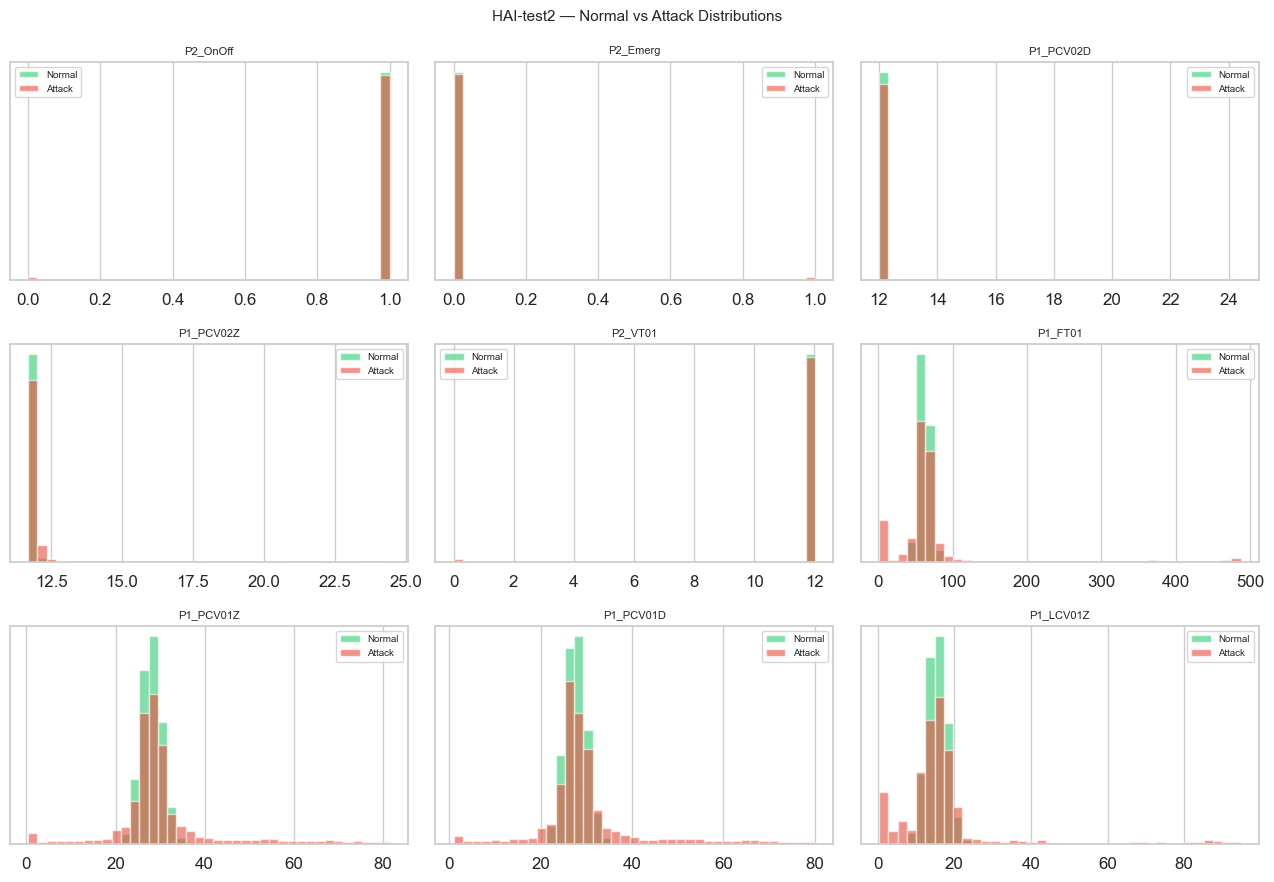

c:\Users\ahmma\anaconda3\envs\digital_twin\lib\site-packages\numpy\lib\_histograms_impl.py:901: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
c:\Users\ahmma\anaconda3\envs\digital_twin\lib\site-packages\numpy\lib\_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


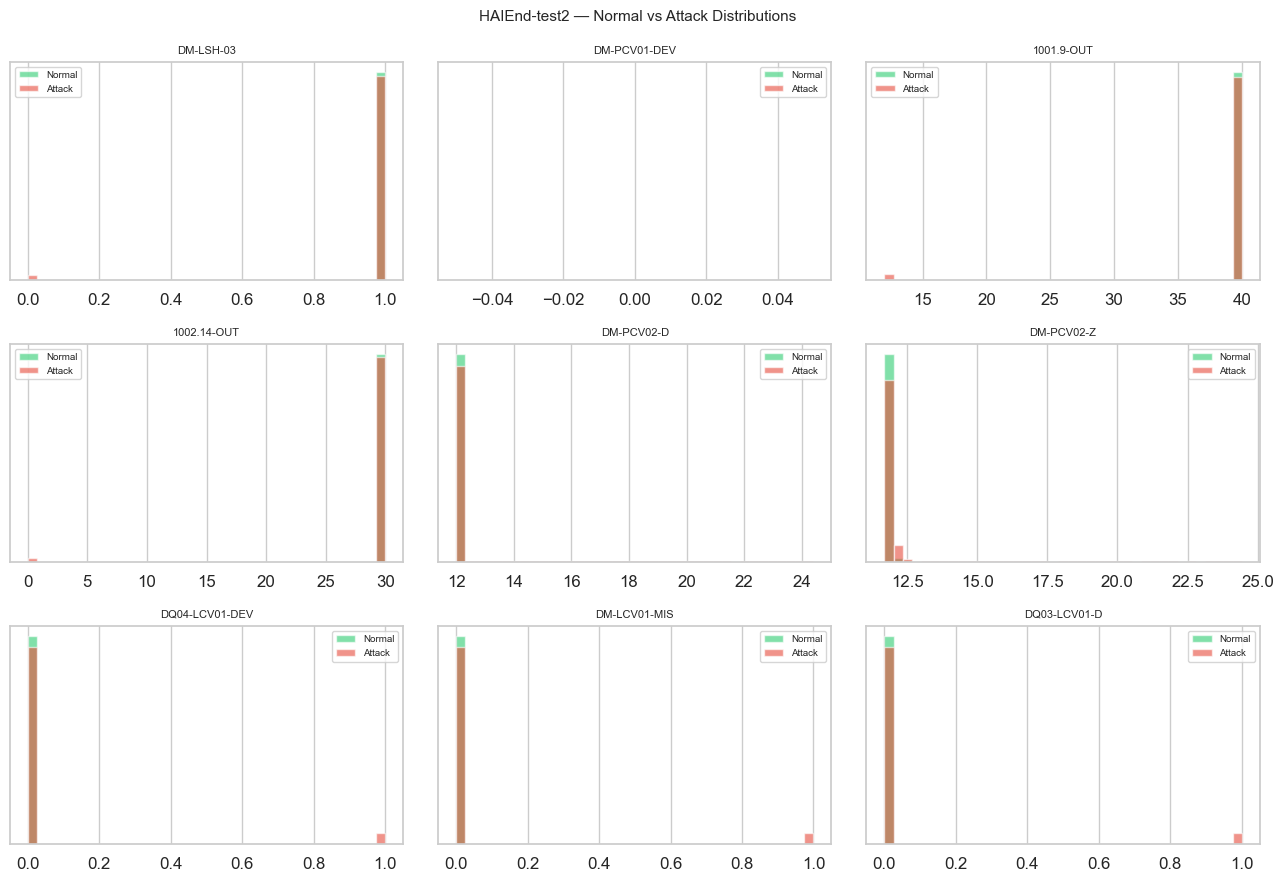

In [14]:
import numpy as np

def plot_distributions(df, top_sensors, title_prefix):
    normal = df[df["attack_type"] == "normal"]
    attack = df[df["attack_type"] != "normal"]
    cols = top_sensors.index[:9].tolist()
    fig, axes = plt.subplots(3, 3, figsize=(13, 9))
    for ax, col in zip(axes.flat, cols):
        n_vals = normal[col].dropna()
        a_vals = attack[col].dropna()
        lo = min(n_vals.quantile(0.01), a_vals.quantile(0.01))
        hi = max(n_vals.quantile(0.99), a_vals.quantile(0.99))
        bins = np.linspace(lo, hi, 40)
        ax.hist(n_vals, bins=bins, alpha=0.6, color="#2ecc71", density=True, label="Normal")
        ax.hist(a_vals, bins=bins, alpha=0.6, color="#e74c3c", density=True, label="Attack")
        ax.set_title(col, fontsize=8)
        ax.legend(fontsize=7)
        ax.set_yticks([])
    plt.suptitle(f"{title_prefix} — Normal vs Attack Distributions", fontsize=11)
    plt.tight_layout()
    plt.show()

plot_distributions(hai2, top_hai, "HAI-test2")
plot_distributions(end2, top_end, "HAIEnd-test2")

---
## 10. Constant Sensors — Remove or Keep?

A sensor constant across ALL time (normal + attack) carries no information.
But a sensor constant in training that **changes during attacks** is a critical signal — removing it is dangerous.

| Case | Verdict |
|------|---------|
| Constant in train AND test (normal + attack) | **Remove** — zero information |
| Constant in train, **changes in normal test** | Keep — system operating range expanded |
| Constant in train, **changes only during attack** | **Must keep** — the change IS the attack signal |


In [15]:
# Use hai-test2 (largest, most attack types)
df = dfs["hai-test2"].copy()

META = {"timestamp", "attack_id", "scenario", "attack_type",
        "combination", "target_controller", "target_points"}
sensor_cols = [c for c in df.select_dtypes(include=["number"]).columns
               if c.lower() not in {m.lower() for m in META}]

is_normal = df["attack_type"] == "normal"
is_attack = df["attack_type"] != "normal"

normal_df = df[is_normal][sensor_cols]
attack_df = df[is_attack][sensor_cols]
full_df   = df[sensor_cols]

# A sensor is "constant" if std < threshold
STD_THRESH = 0.01

const_full   = full_df.std()   < STD_THRESH   # constant across ALL time
const_normal = normal_df.std() < STD_THRESH   # constant in normal periods
const_attack = attack_df.std() < STD_THRESH   # constant during attacks

# Classify each constant-in-full sensor
const_cols = const_full[const_full].index.tolist()

results = []
for col in const_cols:
    c_norm = normal_df[col].std() < STD_THRESH
    c_atk  = attack_df[col].std() < STD_THRESH
    if c_norm and c_atk:
        verdict = "REMOVE — constant always"
    elif c_norm and not c_atk:
        verdict = "KEEP — changes during attack (signal!)"
    else:
        verdict = "KEEP — changes in normal op"
    results.append({"sensor": col,
                    "std_full": round(full_df[col].std(), 5),
                    "std_normal": round(normal_df[col].std(), 5),
                    "std_attack": round(attack_df[col].std(), 5),
                    "verdict": verdict})

res_df = pd.DataFrame(results).sort_values("verdict")
print(f"Sensors constant across ALL time (std < {STD_THRESH}): {len(const_cols)}")
print()
print(res_df.to_string(index=False))


Sensors constant across ALL time (std < 0.01): 21

     sensor  std_full  std_normal  std_attack                  verdict
P1_PIT01_HH   0.00000     0.00000     0.00000 REMOVE — constant always
    P3_LL01   0.00000     0.00000     0.00000 REMOVE — constant always
    P3_LH01   0.00000     0.00000     0.00000 REMOVE — constant always
   P2_VTR04   0.00000     0.00000     0.00000 REMOVE — constant always
   P2_VTR03   0.00000     0.00000     0.00000 REMOVE — constant always
   P2_VTR02   0.00000     0.00000     0.00000 REMOVE — constant always
   P2_VTR01   0.00000     0.00000     0.00000 REMOVE — constant always
  P2_TripEx   0.00000     0.00000     0.00000 REMOVE — constant always
     P2_RTR   0.00000     0.00000     0.00000 REMOVE — constant always
   P4_HT_FD   0.00209     0.00209     0.00222 REMOVE — constant always
   P2_24Vdc   0.00350     0.00351     0.00345 REMOVE — constant always
  P1_SOL03D   0.00000     0.00000     0.00000 REMOVE — constant always
  P1_SOL01D   0.00000     

In [16]:
# Summary counts
verdict_counts = res_df["verdict"].value_counts()
print("Summary:")
for v, n in verdict_counts.items():
    print(f"  {n:>3}  {v}")

remove_list = res_df[res_df["verdict"].str.startswith("REMOVE")]["sensor"].tolist()
keep_list   = res_df[~res_df["verdict"].str.startswith("REMOVE")]["sensor"].tolist()

print(f"\nSafe to remove: {len(remove_list)} sensors")
print(f"Must keep     : {len(keep_list)} sensors")

# Plot: show one "keep" sensor — flat in normal, changes in attack
if keep_list:
    col = keep_list[0]
    fig, ax = plt.subplots(figsize=(14, 3))
    ax.plot(df["timestamp"], df[col], lw=0.7, color="steelblue", label=col)
    # shade attack windows
    attack_mask = df["attack_type"] != "normal"
    ax.fill_between(df["timestamp"], df[col].min(), df[col].max(),
                    where=attack_mask, alpha=0.3, color="tomato", label="Attack")
    ax.set_title(f"{col} — constant in normal, CHANGES during attack")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("All constant sensors are safe to remove.")


Summary:
   21  REMOVE — constant always

Safe to remove: 21 sensors
Must keep     : 0 sensors
All constant sensors are safe to remove.
